# 04 — Análisis Regional
## Pipeline CAD-TBX11K | Diagnóstico Asistido por Computador en Tuberculosis

La tuberculosis pulmonar activa afecta preferentemente los **lóbulos superiores** del pulmón.
Este notebook investiga si esa predilección anatómica es cuantificable a partir de la
distribución espacial de la intensidad en las radiografías.

### Objetivo

Justificar empíricamente por qué en `05_Extraccion_Caracteristicas.ipynb` se calculan
características **por región anatómica** además de características globales.  Si la señal
discriminativa estuviera distribuida uniformemente, las features regionales no aportarían
información adicional.

### División anatómica (imagen 256×256)

```
┌─────────────┬─────────────┐
│  SI         │  SD         │  ← zona superior  (filas 0–85)
├─────────────┼─────────────┤
│  MI         │  MD         │  ← zona media      (filas 86–170)
├─────────────┼─────────────┤
│  II         │  ID         │  ← zona inferior   (filas 171–255)
└─────────────┴─────────────┘
     col 0–127    col 128–255
```

SI = Superior Izquierdo, SD = Superior Derecho, MI = Medio Izquierdo,
MD = Medio Derecho, II = Inferior Izquierdo, ID = Inferior Derecho.



## 0. Configuración del entorno

In [1]:
# Se configura el path del proyecto y se importan las funciones del framework.

import sys, os, warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd

from src.data import download_dataset, get_data_root, build_base_dataframe
from src.features import REGIONS
from src.visualization import (
    set_publication_style,
    plot_regions_on_images,
    compute_regional_stats,
    plot_regional_heatmap,
    plot_regional_distributions,
    build_regional_comparison_table,
)

set_publication_style()
print('Entorno configurado correctamente.')
print('\nRegiones anatómicas definidas:')
for nombre, (x, y, w, h) in REGIONS.items():
    print(f'  {nombre}: x={x}, y={y}, w={w}, h={h}')

Entorno configurado correctamente.

Regiones anatómicas definidas:
  SI: x=0, y=0, w=128, h=86
  SD: x=128, y=0, w=128, h=86
  MI: x=0, y=86, w=128, h=85
  MD: x=128, y=86, w=128, h=85
  II: x=0, y=171, w=128, h=85
  ID: x=128, y=171, w=128, h=85


## 1. Carga del DataFrame base

In [2]:
# Se carga el DataFrame base desde data/df_base.csv.
# Si aún no existe, ejecutar primero el notebook 01 para generarlo.
from pathlib import Path
CSV_PATH = Path('..') / 'data' / 'df_base.csv'

if CSV_PATH.exists():
    df_base = pd.read_csv(CSV_PATH)
    print(f'DataFrame cargado desde: {CSV_PATH.resolve()}')
    print(f'Total imágenes: {len(df_base)}')
else:
    print(f'[ERROR] No se encontró: {CSV_PATH.resolve()}')
    print('Ejecuta primero el notebook 01 para generar df_base.csv')

print()
print(df_base['class_name'].value_counts())

DataFrame cargado desde: C:\Users\bernarda.salazar\Documents\GitHub\CAD_TBX11K\data\df_base.csv
Total imágenes: 30

class_name
health    10
sick      10
tb        10
Name: count, dtype: int64


## 2. Visualización de las regiones sobre las imágenes

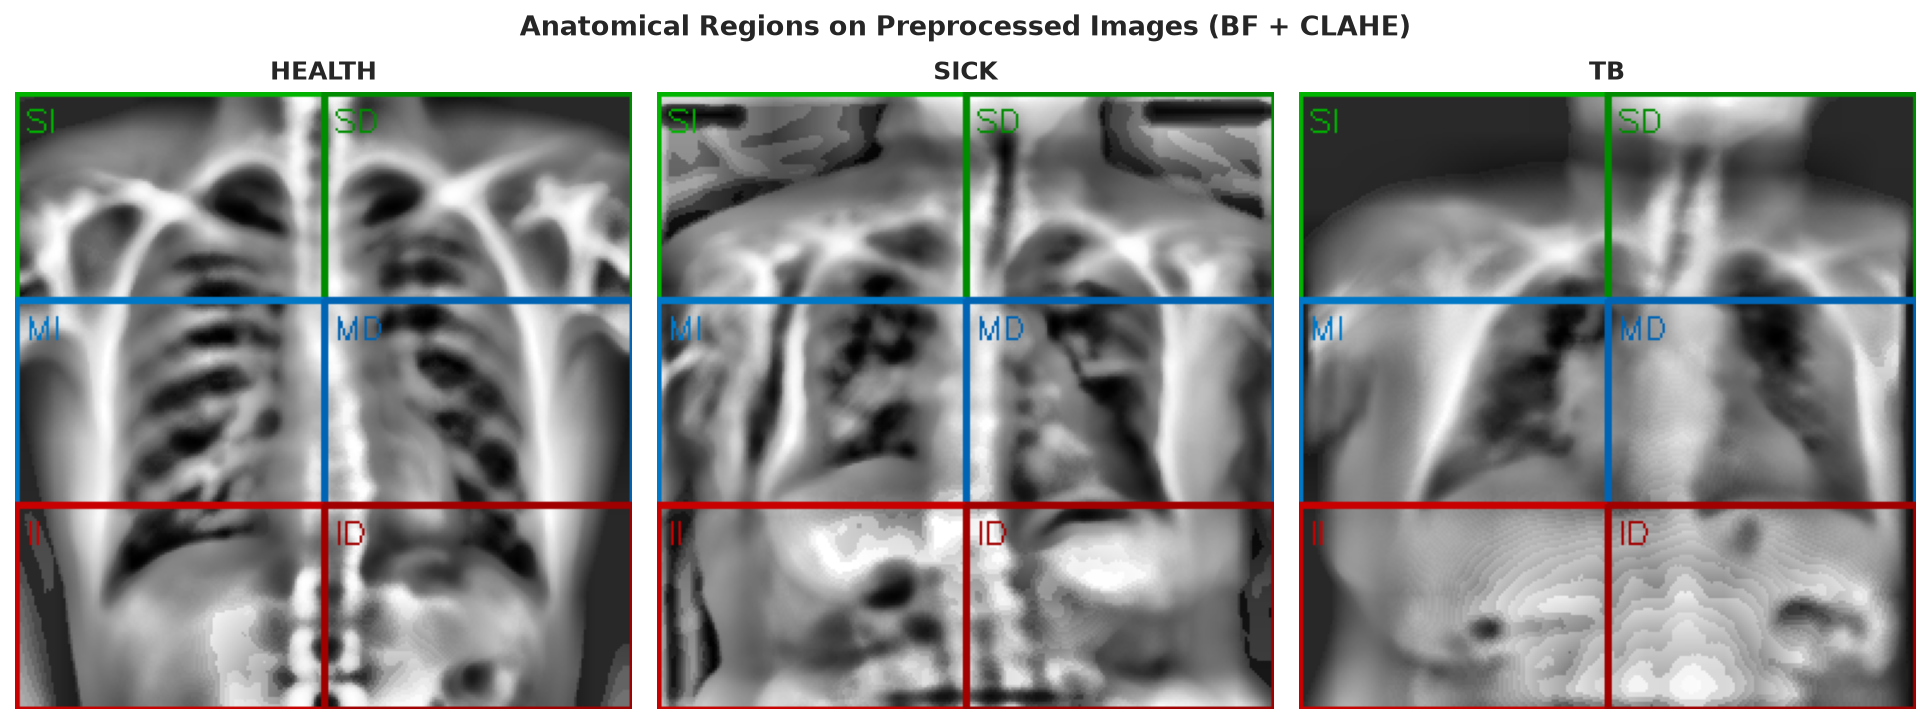

In [3]:
# Se superponen los bordes de las seis regiones anatómicas sobre una imagen
# preprocesada de cada clase. La visualización permite verificar que la división
# es anatómicamente coherente (las zonas superiores corresponden a los ápices pulmonares).

plot_regions_on_images(df_base)

## 3. Intensidad media por región y clase

In [4]:
# Se calcula la intensidad media en cada región para n imágenes por clase.
# Si la TB afecta más los lóbulos superiores (SI, SD), se espera que esas regiones
# presenten mayor intensidad en imágenes `tb` respecto a `health`.

N_REG = min(60, len(df_base[df_base['class_name'] == 'health']))
reg_df = compute_regional_stats(df_base, n_reg=N_REG, random_state=42)

print(f'Mean intensity per region and class (n={N_REG} per class):')
region_cols = [f'{r}_mean' for r in REGIONS]
print(reg_df.groupby('class_name')[region_cols].mean().round(2).to_string())

Mean intensity per region and class (n=10 per class):
            SI_mean  SD_mean  MI_mean  MD_mean  II_mean  ID_mean
class_name                                                      
health       119.73   121.60   123.36   128.43   124.85   120.87
sick         126.38   128.71   125.35   130.55   145.17   143.00
tb           122.54   125.56   124.24   124.82   137.58   134.59


## 4. Mapa de calor — intensidad regional

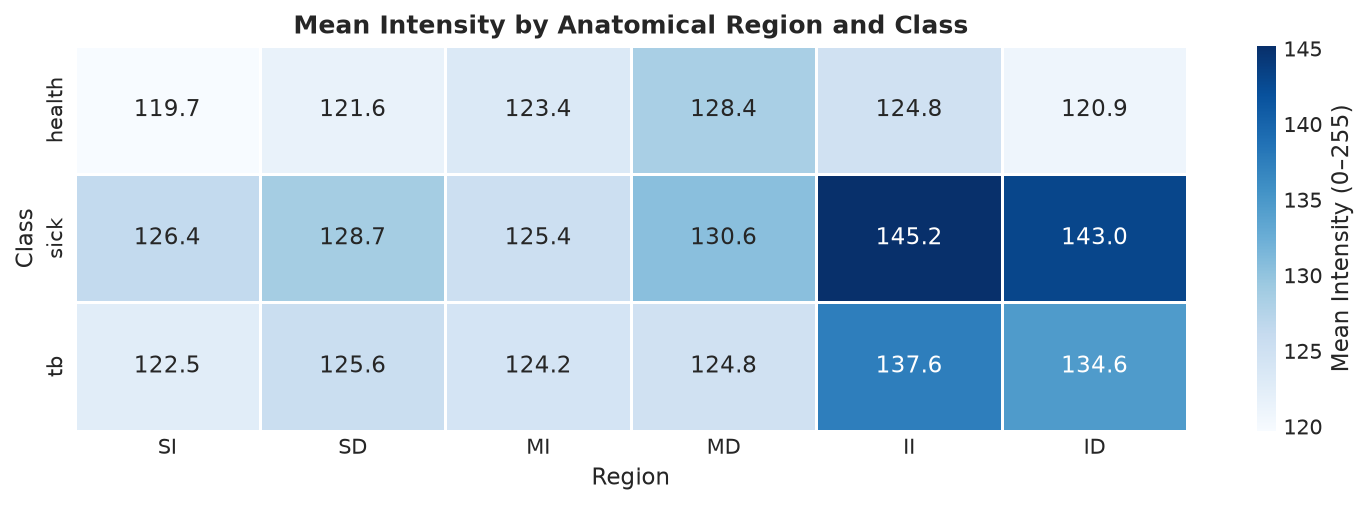

In [5]:
# El mapa de calor resume en una sola figura la intensidad media por región y clase.
# Permite identificar de un vistazo qué regiones presentan mayor diferencia entre clases.


plot_regional_heatmap(reg_df)

## 5. Distribuciones de intensidad regional

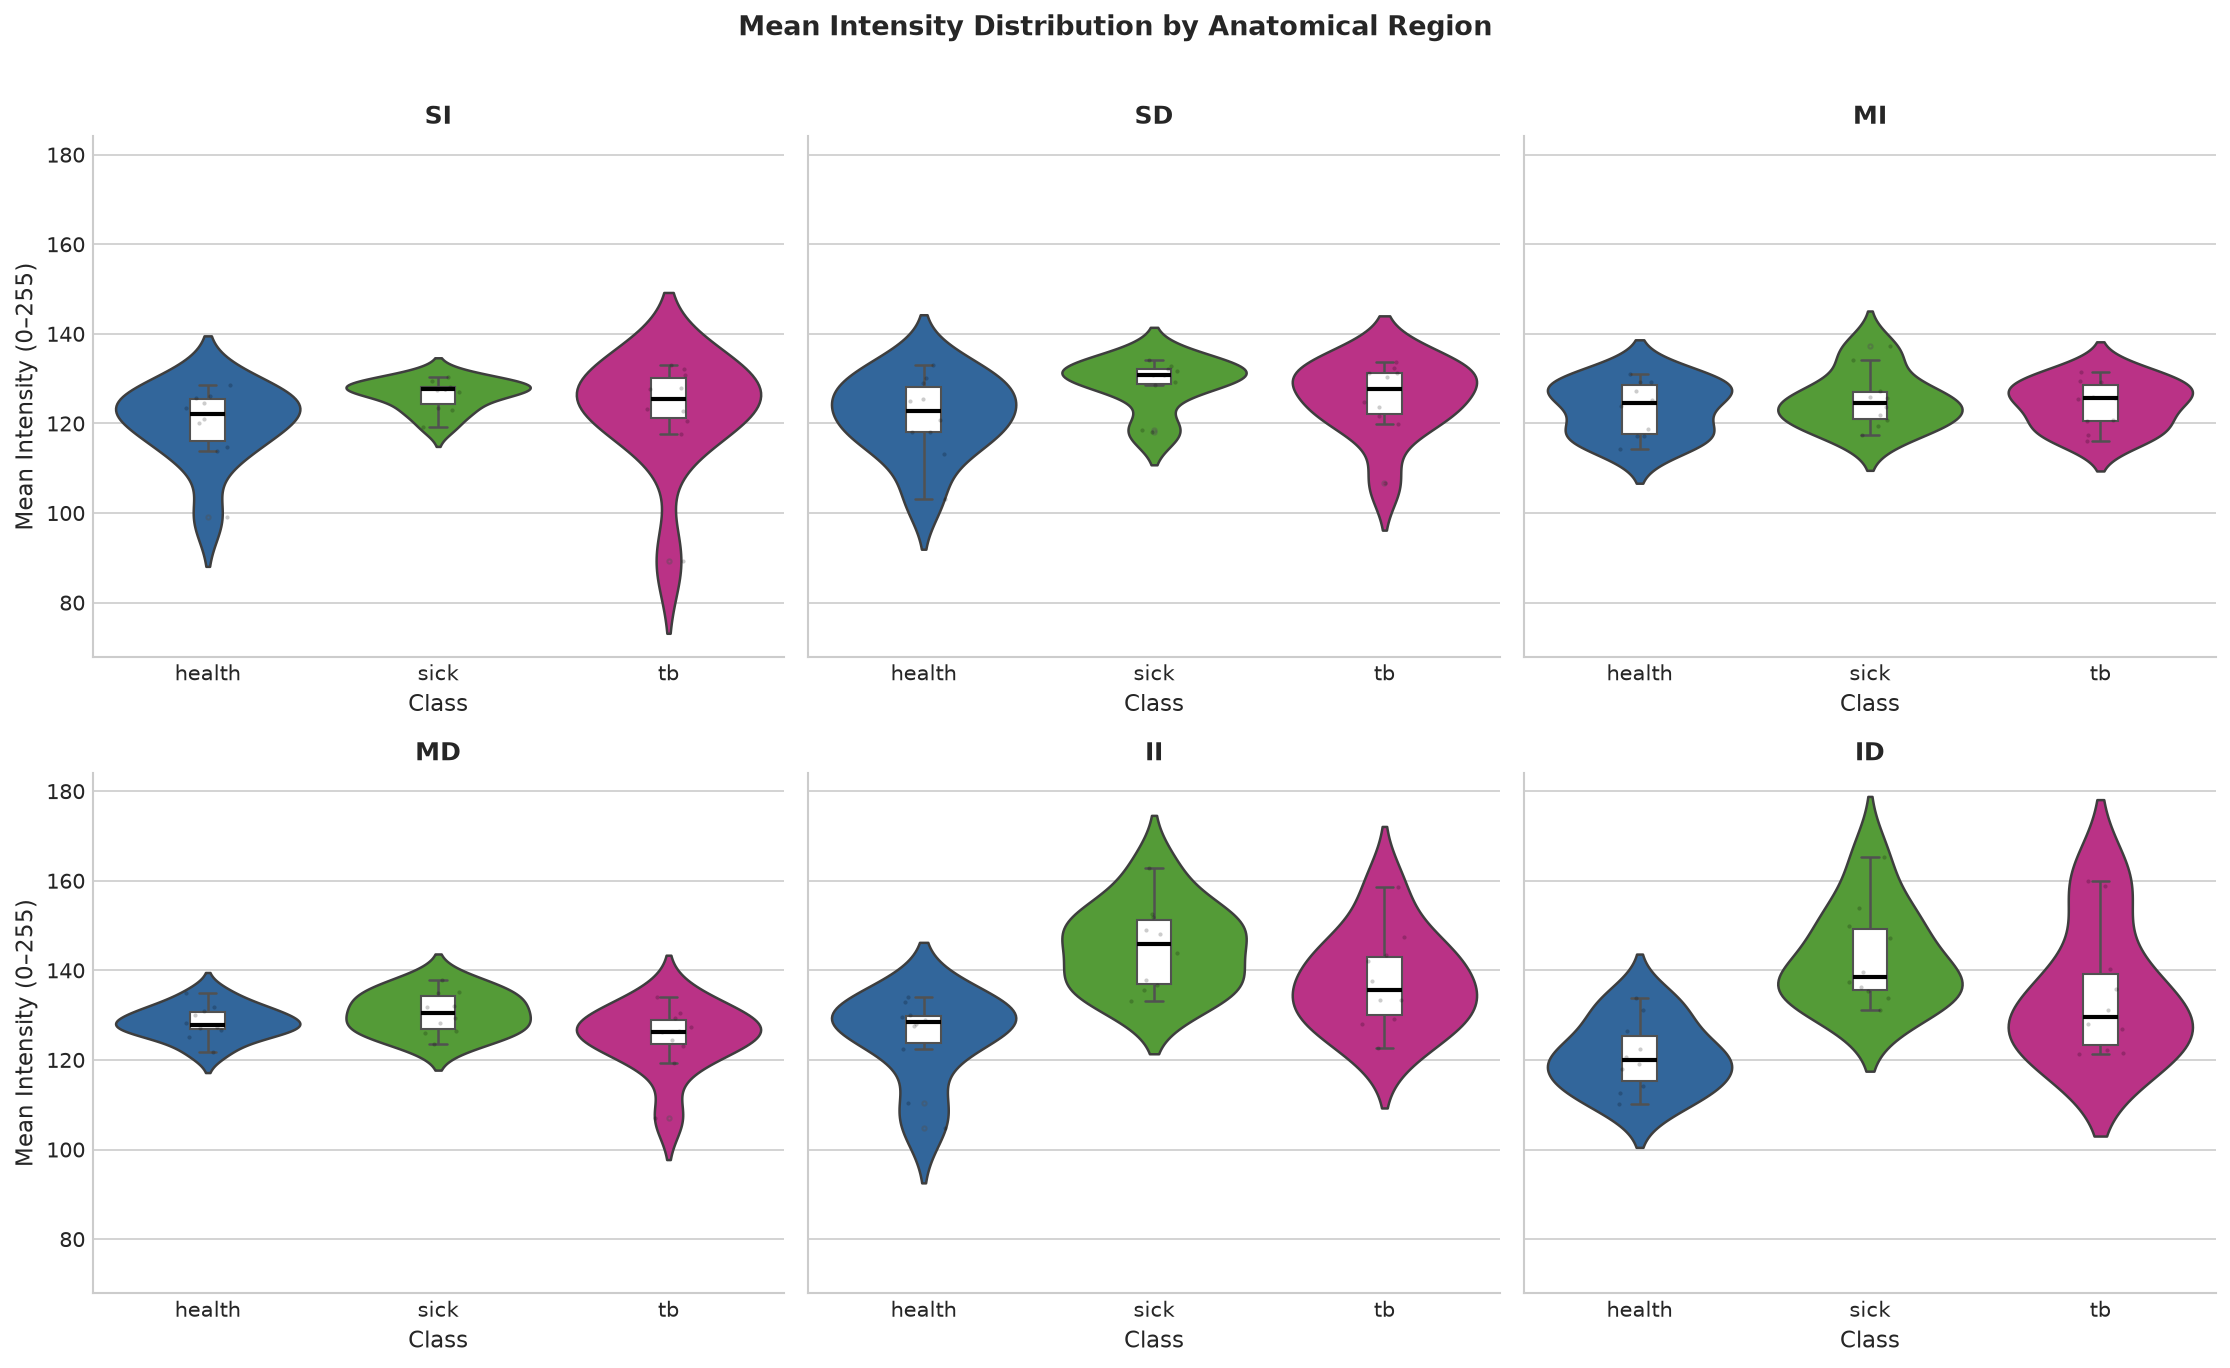

In [6]:
# Los violin plots descomponen la distribución de intensidad en cada región.
# La superposición con box plots permite evaluar si las diferencias observadas
# en el mapa de calor son consistentes (varianza baja) o están dominadas por outliers.

plot_regional_distributions(reg_df)

## 6. Tabla comparativa de regiones

In [7]:
# Se construye una tabla resumen con el formato `media ± desviación estándar`
# por región y clase. Esta tabla es adecuada para incluir en informes o artículos.

tabla_regional = build_regional_comparison_table(reg_df)

print('Intensidad media ± desviación estándar por región anatómica:')
print('(sobre 60 imágenes por clase, preprocesadas con BF + CLAHE)')
print()
print(tabla_regional.to_string())

Intensidad media ± desviación estándar por región anatómica:
(sobre 60 imágenes por clase, preprocesadas con BF + CLAHE)

                      SI           SD           MI           MD            II            ID
class_name                                                                                 
health       119.7 ± 8.7  121.6 ± 8.9  123.4 ± 6.0  128.4 ± 3.7   124.8 ± 9.7   120.9 ± 7.7
sick         126.4 ± 3.4  128.7 ± 5.7  125.4 ± 6.3  130.6 ± 4.6   145.2 ± 9.4  143.0 ± 10.8
tb          122.5 ± 12.8  125.6 ± 8.3  124.2 ± 5.3  124.8 ± 7.4  137.6 ± 10.6  134.6 ± 14.4


## 7. Diferencia relativa entre clases por región

In [8]:
# Se cuantifica la diferencia relativa entre `tb` y `health` en cada región.
# Las regiones con mayor diferencia relativa son las más discriminativas
# y justifican la inclusión de features regionales en el notebook 05.

region_cols = [f'{r}_mean' for r in REGIONS]
medias = reg_df.groupby('class_name')[region_cols].mean()

print('Diferencia relativa entre tb y health por región (|tb - health| / health × 100):')
print()
for col in region_cols:
    val_health = medias.loc['health', col]
    val_tb     = medias.loc['tb', col]
    dif_rel    = abs(val_tb - val_health) / (abs(val_health) + 1e-9) * 100
    region     = col.replace('_mean','')
    print(f'  {region}: health={val_health:.1f}  tb={val_tb:.1f}  Δ={dif_rel:.1f}%')

Diferencia relativa entre tb y health por región (|tb - health| / health × 100):

  SI: health=119.7  tb=122.5  Δ=2.3%
  SD: health=121.6  tb=125.6  Δ=3.3%
  MI: health=123.4  tb=124.2  Δ=0.7%
  MD: health=128.4  tb=124.8  Δ=2.8%
  II: health=124.8  tb=137.6  Δ=10.2%
  ID: health=120.9  tb=134.6  Δ=11.4%


## Conclusiones

Con base en el análisis regional se observa que:

- Las **regiones inferiores (II, ID)** presentan la mayor diferencia relativa entre `health` y `tb`
  (10.2% y 11.4% respectivamente), contrario a lo esperado por la fisiopatología clásica de la TB
  que afecta preferentemente los lóbulos superiores. Esto puede deberse al tamaño reducido de la
  muestra (n=10) o a características propias del dataset TBX11K.
- Las **regiones superiores (SI, SD)** muestran diferencias moderadas (2.3% y 3.3%), presentes
  pero no dominantes en esta muestra.
- Las **regiones medias (MI, MD)** presentan las menores diferencias (0.7% y 2.8%), lo que
  sugiere menor capacidad discriminativa en esas zonas.
- Todas las regiones presentan algún nivel de diferencia entre clases, lo que **justifica la
  inclusión de features regionales** en el notebook 05.
- MI podría ser candidata a exclusión en etapas de selección de características dado su Δ < 1%.

> **Nota:** Con n=10 imágenes estos resultados son orientativos. Ejecutar con `N_MUESTRA = None`
> para determinar qué regiones son estadísticamente relevantes.

**Siguiente etapa:** `05_Extraccion_Caracteristicas.ipynb`
